In [4]:
import os
import numpy as np
import pandas as pd
import stylia
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 300
from stylia import CategoricalPalette

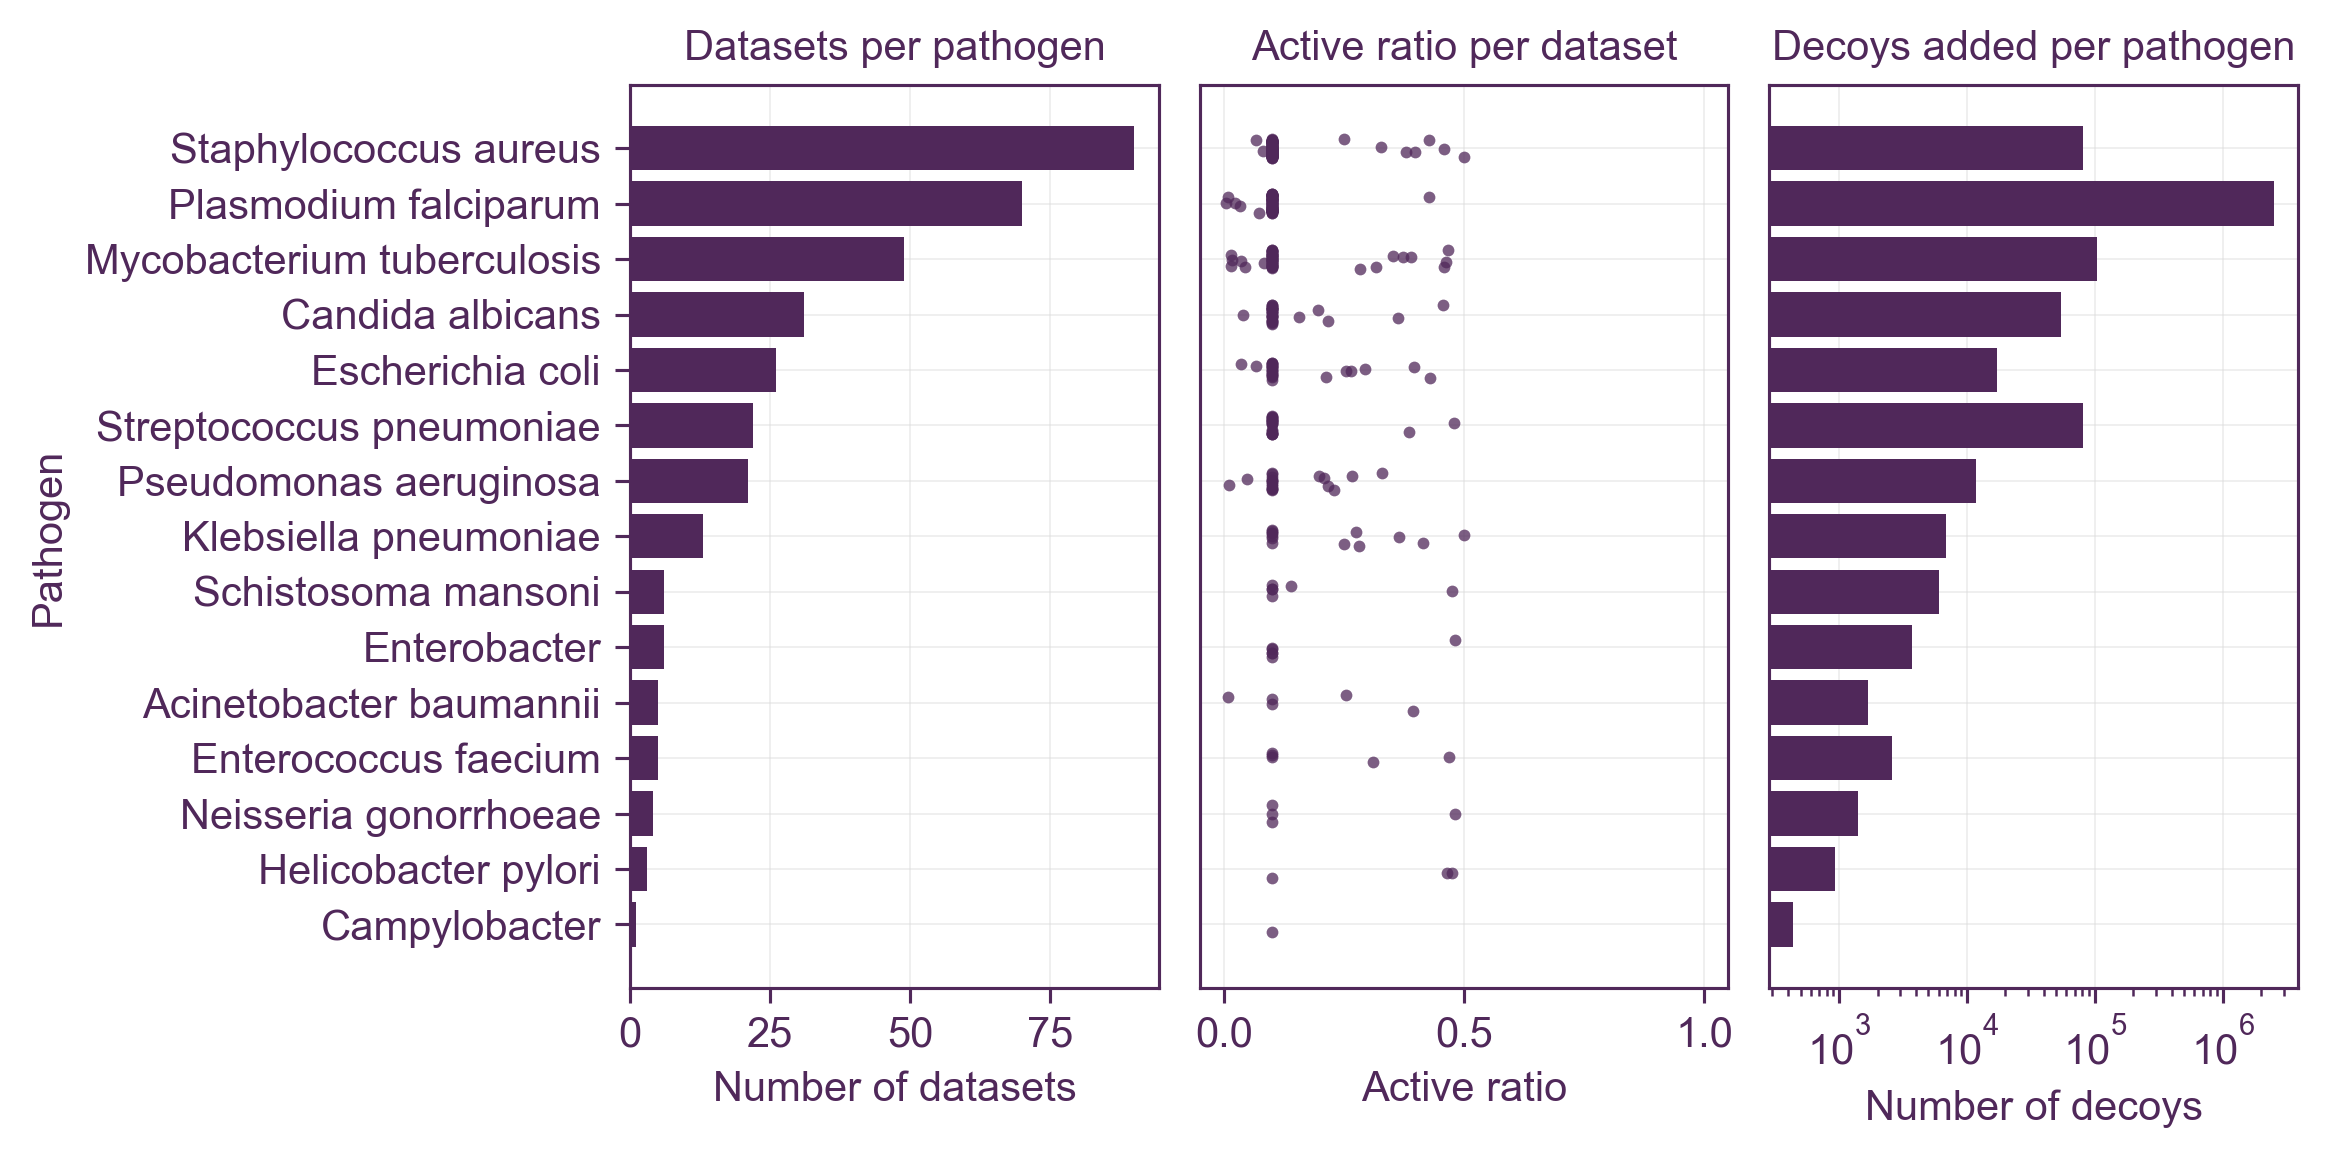

In [8]:
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

metadata = pd.read_csv(os.path.join(REPO_ROOT, "output", "results", "06_datasets_metadata.csv"))
pathogens = pd.read_csv(os.path.join(REPO_ROOT, "config", "pathogens.csv"))

code_to_name = dict(zip(pathogens["code"], pathogens["pathogen"]))

counts = (
    metadata.groupby("pathogen")
    .size()
    .reset_index(name="n_datasets")
    .sort_values("n_datasets", ascending=True)
)
counts["name"] = counts["pathogen"].map(code_to_name)

# preserve pathogen order for the scatter
pathogen_order = counts["pathogen"].tolist()
metadata["name"] = metadata["pathogen"].map(code_to_name)
metadata["pathogen_rank"] = metadata["pathogen"].map({p: i for i, p in enumerate(pathogen_order)})

metadata = metadata.copy()
rng = np.random.default_rng(42)
jitter_strength = 0.18
metadata["pathogen_y_jitter"] = (
    metadata["pathogen_rank"] +
    rng.uniform(-jitter_strength, jitter_strength, size=len(metadata)))

stylia.set_format("slide")
stylia.set_style("ersilia")

pal = CategoricalPalette("ersilia")
color = pal.get(8)[0]

pathogen_order = counts["name"].tolist()
pathogen_to_y = {name: i for i, name in enumerate(pathogen_order)}
counts = counts.copy()
counts["pathogen_y"] = counts["name"].map(pathogen_to_y)

decoy_counts = (
    metadata.groupby("name")["decoys"]
    .sum()
    .reset_index(name="n_decoys")
)
decoy_counts["pathogen_y"] = decoy_counts["name"].map(pathogen_to_y)
decoy_counts = decoy_counts.sort_values("pathogen_y")

fig, axs = stylia.create_figure(1, 3, width=0.6, height=0.3)

ax_a = axs.next()
ax_a.barh(counts["pathogen_y"], counts["n_datasets"], color=color)
ax_a.set_yticks(counts["pathogen_y"])
ax_a.set_yticklabels(counts["name"])
ax_a.set_xlabel("Number of datasets")
ax_a.set_ylabel("Pathogen")
stylia.label(ax_a, title="Datasets per pathogen")

ax_b = axs.next()
ax_b.sharey(ax_a)
ax_b.scatter(metadata["final_ratio"], metadata["pathogen_y_jitter"], color=color, s=stylia.MARKERSIZE_SMALL, alpha=0.75)
ax_b.set_xlabel("Active ratio")
ax_b.set_ylabel("")
ax_b.set_xlim([-0.05, 1.05])
ax_b.tick_params(axis="y", left=False, labelleft=False)
stylia.label(ax_b, title="Active ratio per dataset")

ax_c = axs.next()
ax_c.set_xscale('log')
ax_c.sharey(ax_a)
ax_c.barh(decoy_counts["pathogen_y"], decoy_counts["n_decoys"], color=color)
ax_c.set_xlabel("Number of decoys")
ax_c.set_ylabel("")
ax_c.tick_params(axis="y", left=False, labelleft=False)
stylia.label(ax_c, title="Decoys added per pathogen")